## In this problem, you will generate simulated data, and then perform PCA and K-means clustering on the data.

### (a)

Generate a simulated data set with 20 observations in each of three classes (i.e. 60 observations total), and 50 variables.
Hint: There are a number of functions in Python that you can use to generate data. One example is the normal() method of the random() function in numpy; the uniform() method is another option. Be sure to add a mean shift to the observations in each class so that there are three distinct classes.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns


In [15]:
#產生模擬資料：三類，每類 20 筆，共 60 筆，每筆 50 個變數
np.random.seed(0) #希望亂數在每次執行時的結果是相同的
n_per_class = 20
n_features = 50

# 三類資料，平均分別為 -3, 0, 3，標準差 1
class1 = np.random.normal(loc=0.0, scale=2.0, size=(n_per_class, n_features))
class2 = np.random.normal(loc=3.0, scale=2.0, size=(n_per_class, n_features))
class3 = np.random.normal(loc=-3.0, scale=2.0, size=(n_per_class, n_features))
# 合併資料
X = np.vstack([class1, class2, class3])
y_true = np.array([0]*n_per_class + [1]*n_per_class + [2]*n_per_class) #建立資料的真實標籤（labels），每一筆資料是屬於哪一類（class 0、1 或 2）。

### (b)

Perform PCA on the 60 observations and plot the first two prin- cipal component score vectors. Use a different color to indicate the observations in each of the three classes. If the three classes appear separated in this plot, then continue on to part (c). If not, then return to part (a) and modify the simulation so that there is greater separation between the three classes. Do not continue to part (c) until the three classes show at least some separation in the first two principal component score vectors.

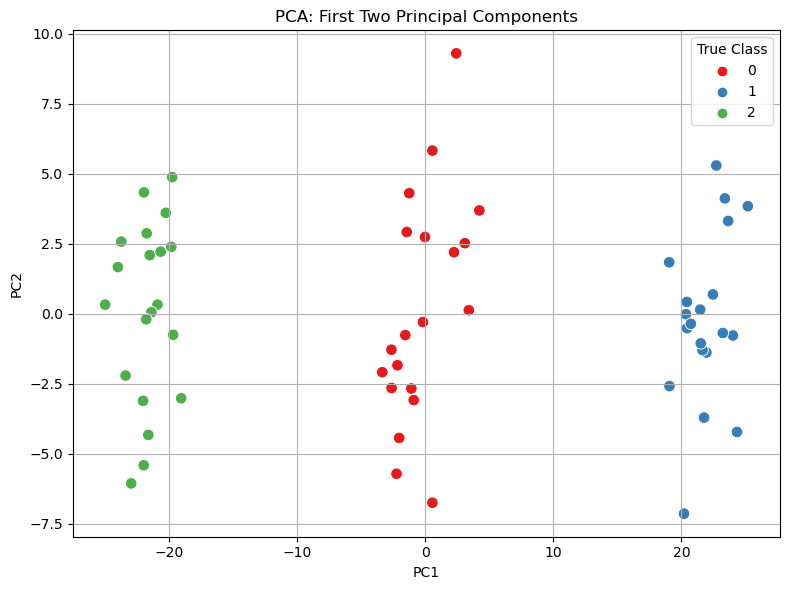

In [16]:

# (b) 使用 PCA 並畫出前兩個主成分
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true, palette="Set1", s=70)
plt.title('PCA: First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.legend(title="True Class")
plt.tight_layout()
plt.show()

## (c)

Perform K-means clustering of the observations with K = 3. How well do the clusters that you obtained in K-means clustering compare to the true class labels?
Hint: You can use the pd.crosstab() function in Python to compare the true class labels to the class labels obtained by clustering. Be careful how you interpret the results: K-means clustering will arbitrarily number the clusters, so you cannot simply check whether the true class labels and clustering labels are the same.

In [17]:
# K-means 分群（K=3），並與真實類別比對
kmeans_3 = KMeans(n_clusters=3, random_state=0, n_init=10)
clusters_3 = kmeans_3.fit_predict(X)
crosstab_3 = pd.crosstab(y_true, clusters_3)
print("\n(c) K=3 分群結果與真實類別對照：")
print(crosstab_3)



(c) K=3 分群結果與真實類別對照：
col_0   0   1   2
row_0            
0       0   0  20
1      20   0   0
2       0  20   0


The vertical line shows the true label.
<br>
The classification result is completely correct; it's just that the resulting label differs from the true label!

## (d)

Perform K-means clustering with K = 2. Describe your results.

In [18]:
#K=2 分群
kmeans_2 = KMeans(n_clusters=2, random_state=0, n_init=10)
clusters_2 = kmeans_2.fit_predict(X)
crosstab_2 = pd.crosstab(y_true, clusters_2)
print("\n(d) K=2 分群結果與真實類別對照：")
print(crosstab_2)


(d) K=2 分群結果與真實類別對照：
col_0   0   1
row_0        
0       0  20
1      20   0
2       0  20


0 and 2 are all grouped together

### (e)

Now perform K-means clustering with K = 4, and describe your
results.

In [19]:
#K=4 分群
kmeans_4 = KMeans(n_clusters=4, random_state=0, n_init=10)
clusters_4 = kmeans_4.fit_predict(X)
crosstab_4 = pd.crosstab(y_true, clusters_4)
print("\n(e) K=4 分群結果與真實類別對照：")
print(crosstab_4)



(e) K=4 分群結果與真實類別對照：
col_0   0   1   2   3
row_0                
0       0   0  20   0
1       0  20   0   0
2      10   0   0  10


1 and 2 are correctly classified, only 0 is divided into two groups

### (f)

Now perform K-means clustering with K = 3 on the first two principal component score vectors, rather than on the raw data. That is, perform K-means clustering on the 60 × 2 matrix of which the first column is the first principal component score vector, and the second column is the second principal component score vector. Comment on the results.

In [20]:
#在前兩個 PCA 主成分上做 K=3 的分群
kmeans_pca = KMeans(n_clusters=3, random_state=0, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)
crosstab_pca = pd.crosstab(y_true, clusters_pca)
print("\n(f) K=3 (PCA 資料) 分群結果與真實類別對照：")
print(crosstab_pca)


(f) K=3 (PCA 資料) 分群結果與真實類別對照：
col_0   0   1   2
row_0            
0       0   0  20
1      20   0   0
2       0  20   0


The result is consistent with (c)

### (g)

Using the StandardScaler() estimator, perform K-means clus- tering with K = 3 on the data after scaling each variable to have standard deviation one. How do these results compare to those obtained in (b)? Explain.

In [21]:
#對原始資料做標準化再 K=3 分群
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_scaled = kmeans_scaled.fit_predict(X_scaled)
crosstab_scaled = pd.crosstab(y_true, clusters_scaled)
print("\n(g) K=3 (標準化後資料) 分群結果與真實類別對照：")
print(crosstab_scaled)


(g) K=3 (標準化後資料) 分群結果與真實類別對照：
col_0   0   1   2
row_0            
0       0   0  20
1      20   0   0
2       0  20   0


The result is the same as (b), only the labels are different